# Training a sample low-rank RNN and a full-rank (unconstrained) RNN

This notebook is a minimal, self-contained example of how the recurrent networks in
*"Parametric control of flexible timing through low-dimensional neural manifolds"* (Beiran, Meirhaeghe et al., 2022)
are trained, using the `modules4.py` (network classes + training loop) and `funcs_Sphere.py` (task generation)
helper modules already in this repository.

We train two networks from scratch (random initialization, no pretrained weights needed) on a simplified version
of the **CSG ("Ready-Set-Go" style interval reproduction) task**: the network sees a constant background input whose
amplitude sets a target time interval, a brief "Ready" pulse, and must ramp its output from 0 to 1, crossing a
threshold exactly `t_s` ms later (where `t_s` depends linearly on the cue amplitude).

- **Low-rank RNN** (`OptimizedLowRankRNN`): recurrent connectivity is constrained to `J = m n^T`, i.e. rank `r` ≡
  a low-dimensional dynamical system.
- **Full-rank / unconstrained RNN** (`FullRankRNN`): a standard, unconstrained recurrent connectivity matrix.

Both use the same continuous-time leaky-RNN dynamics, the same task, and the same training loop (`modules4.train`,
Adam + gradient clipping + MSE loss on a masked window). Sizes/epoch counts below are picked to run in a couple of
minutes on a laptop CPU — they are *not* tuned to reproduce the paper's figures (see `Fig1_CSG.py` for that, which
uses `hidden_size=1500`, structured initial connectivity, and pretrained checkpoints in `TrainedNets/`).

In [64]:
import numpy as np
import torch
import matplotlib.pyplot as plt

import modules4 as md      # RNN classes (FullRankRNN, OptimizedLowRankRNN) + train()
import funcs_Sphere as fs  # task generation (create_inp_out2)

torch.manual_seed(0)
np.random.seed(0)

## 1. Task and network hyperparameters

In [65]:
# --- network dynamics ---
dt = 10       # ms, integration step
tau = 100     # ms, single-unit time constant
alpha = dt / tau

# TODO: Why this form of the noise model? It seems to be a standard deviation 
# of the noise injected into each unit, scaled by the square root of 2 * alpha 
# and multiplied by 0.1. This could be related to the discretization of the 
# continuous-time noise process in the RNN dynamics.
std_noise_rec = np.sqrt(2 * alpha) * 0.1   # private noise injected into each unit

input_size = 2    # [cue amplitude (context/speed), "Ready" pulse]
output_size = 1

# --- task (simplified CSG: reproduce one of 4 intervals, cued by input amplitude) ---
Nt = 350                                   # trial length, in steps of dt (= 3500 ms)
R_on = 1000 // dt                          # "Ready" pulse onset, in steps
SR_on = 100 // dt                          # jitter allowed on Ready/Set timing
tss_ms = np.array([800, 1050, 1300, 1550]) # target intervals, in ms
tss = tss_ms // dt                         # ... in steps of dt, as expected by create_inp_out2
amps = np.linspace(0, 0.25, len(tss_ms))   # cue amplitude coding for each interval

trials_train = 200
trials_test = 40
batch_size = 32

print(f"alpha={alpha:.3f}, std_noise_rec={std_noise_rec:.4f}, trial length={Nt*dt} ms")

alpha=0.100, std_noise_rec=0.0447, trial length=3500 ms


In [66]:
# Generate training/test data: input (amp channel + Ready pulse), target output ramp, and loss mask.
input_train, output_train, mask_train, ct_train, ct2_train = fs.create_inp_out2(
    trials_train, Nt, tss, amps, R_on, SR_on, perc=0.1)
input_test, output_test, mask_test, ct_test, ct2_test = fs.create_inp_out2(
    trials_test, Nt, tss, amps, R_on, SR_on, perc=0.1)

print("input_train:", input_train.shape, "output_train:", output_train.shape, "mask_train:", mask_train.shape)

input_train: torch.Size([200, 350, 2]) output_train: torch.Size([200, 350, 1]) mask_train: torch.Size([200, 350, 1])


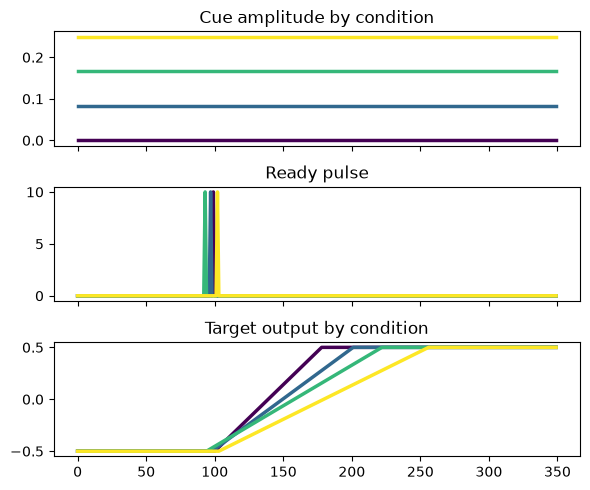

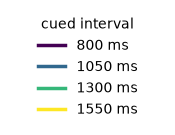

In [67]:
# Plot one sample trial per condition (cued interval), interleaved for comparison
colors = plt.cm.viridis(np.linspace(0, 1, len(tss)))
trial_idxs = [np.where(ct_train == i)[0][0] for i in range(len(tss))]

fig, axes = plt.subplots(3, 1, figsize=(6, 5), sharex=True)
for i, trial_idx in enumerate(trial_idxs):
    axes[0].plot(input_train[trial_idx, :, 0], color=colors[i], lw=2.5, label=f'{tss_ms[i]} ms')
axes[0].set_title('Cue amplitude by condition')

for i, trial_idx in enumerate(trial_idxs):
    axes[1].plot(input_train[trial_idx, :, 1], color=colors[i], lw=2.5)
axes[1].set_title('Ready pulse')

for i, trial_idx in enumerate(trial_idxs):
    axes[2].plot(output_train[trial_idx, :, 0], color=colors[i], lw=2.5)
axes[2].set_title('Target output by condition')
plt.tight_layout()
plt.show()

# Legend as its own small figure
legend_fig = plt.figure(figsize=(2, 1.5))
handles, labels = axes[0].get_legend_handles_labels()
legend_fig.legend(handles, labels, frameon=False, title='cued interval', loc='center')
plt.axis('off')
plt.show()

## 2. Train a low-rank RNN directly on all 4 conditions

`OptimizedLowRankRNN` parametrizes the recurrent connectivity as `J = m @ n.T` with `m, n` of shape
`(hidden_size, rank)`, so the recurrent dynamics live on an `r`-dimensional manifold regardless of `hidden_size`.
We train the input weights, output weights, connectivity vectors (`m`, `n`) and initial state, directly on all
4 cued intervals, starting from the **structured initial connectivity** described in `Fig1_CSG.py`'s
`give_vectors()` — `m`/`n` (and the cue input) are drawn with a built-in correlation, biasing the untrained
network toward a ring-attractor-like manifold instead of pure noise.

Section 3 below trains a second network the same way, except it only ever sees the two **extreme** intervals
(800 & 1550 ms) — the paper's own "2-interval generalization" training procedure — so we can compare how much
that training curriculum (rather than raw `hidden_size`) matters for getting a clean slow manifold.

Training...
initial loss: 0.381
epoch 0:  loss=0.262  (took 1.36 s)
epoch 1:  loss=0.156  (took 1.33 s)
epoch 2:  loss=0.119  (took 1.33 s)
epoch 3:  loss=0.084  (took 1.31 s)
epoch 4:  loss=0.053  (took 1.32 s)
epoch 5:  loss=0.039  (took 1.33 s)
epoch 6:  loss=0.044  (took 1.32 s)
epoch 7:  loss=0.030  (took 1.32 s)
epoch 8:  loss=0.021  (took 1.31 s)
epoch 9:  loss=0.019  (took 1.39 s)
epoch 10:  loss=0.016  (took 1.32 s)
epoch 11:  loss=0.015  (took 1.32 s)
epoch 12:  loss=0.019  (took 1.36 s)
epoch 13:  loss=0.013  (took 1.39 s)
epoch 14:  loss=0.017  (took 1.34 s)
epoch 15:  loss=0.014  (took 1.33 s)
epoch 16:  loss=0.013  (took 1.33 s)
epoch 17:  loss=0.009  (took 1.33 s)
epoch 18:  loss=0.008  (took 1.34 s)
epoch 19:  loss=0.010  (took 1.32 s)
epoch 20:  loss=0.008  (took 1.34 s)
epoch 21:  loss=0.006  (took 1.31 s)
epoch 22:  loss=0.004  (took 1.33 s)
epoch 23:  loss=0.004  (took 1.35 s)
epoch 24:  loss=0.004  (took 1.32 s)
epoch 25:  loss=0.003  (took 1.34 s)
epoch 26:  loss=

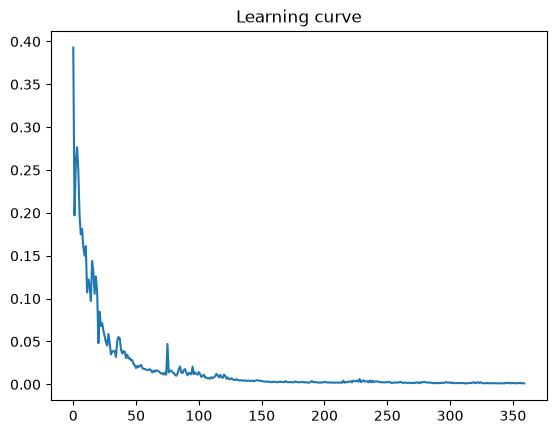

In [68]:
rank = 2
hidden_size_lr = 1500

def give_vectors(sigma1, sigma2, s_m1, s_m2, s=1, hidden_units=1500, max_iter=100, bn2=0.5):
    # Structured initial connectivity, copied from Fig1_CSG.py: draws (m1, n1, m2, n2, input)
    # from a correlated Gaussian so that m/n (and the cue input) overlap from the start,
    # instead of being independent random vectors.
    bigSigma = np.zeros((5, 5))  # 2*rank + input
    bigSigma[0, 0] = s_m1
    bigSigma[1, 1] = s_m2
    bigSigma[2, 2] = 1.
    bigSigma[3, 3] = 1.
    bigSigma[4, 4] = s ** 2
    bigSigma[0, 2] = bigSigma[2, 0] = sigma1
    bigSigma[1, 3] = bigSigma[3, 1] = sigma2
    bigSigma[3, 4] = bigSigma[4, 3] = s * bn2

    stop = False
    ite = 0
    while not stop and ite < max_iter:
        if np.min(np.linalg.eigvals(bigSigma)) < 0:
            bigSigma[2, 2] *= 1.1
            bigSigma[3, 3] *= 1.1
            ite += 1
        else:
            bigSigma[2, 2] *= 1.1
            bigSigma[3, 3] *= 1.1
            stop = True

    mean = np.zeros(5)
    error0 = 10.
    X_save = None
    for _ in range(100):
        X = np.random.multivariate_normal(mean, bigSigma, hidden_units)
        empSig = np.dot(X.T, X) / hidden_units
        error = np.std(empSig - bigSigma)
        if error < error0:
            error0 = error
            X_save = X
    X = X_save

    M = X[:, 0:2]
    N = X[:, 2:4]
    I = X[:, 4]
    return (M, N, I)


def structured_low_rank_init(hidden_size):
    # Draws structured (wi, wo, m, n) initial weights for an OptimizedLowRankRNN of this hidden_size
    Mnaive, Nnaive, Inaive = give_vectors(sigma1=0.8, sigma2=0.8, s_m1=1., s_m2=1., hidden_units=hidden_size)
    Is_naive = np.random.randn() * Mnaive[:, 0] + np.random.randn() * Mnaive[:, 1]
    I_naive = np.vstack((Inaive, Is_naive))
    O_naive = np.random.randn() * Mnaive[:, 0] + np.random.randn() * Mnaive[:, 1]

    dtype = torch.FloatTensor
    m_init = torch.from_numpy(Mnaive / np.sqrt(hidden_size)).type(dtype)
    n_init = torch.from_numpy(Nnaive / np.sqrt(hidden_size)).type(dtype)
    wi_init = torch.from_numpy(I_naive).type(dtype)
    wo_init = torch.from_numpy(O_naive[:, np.newaxis] / hidden_size).type(dtype)
    return wi_init, wo_init, m_init, n_init

wi_init, wo_init, m_init, n_init = structured_low_rank_init(hidden_size_lr)

net_low_rank = md.OptimizedLowRankRNN(
    input_size, hidden_size_lr, output_size, std_noise_rec, alpha,
    rank=rank, train_wi=True, train_wo=True, train_h0=True,
    wi_init=wi_init, wo_init=wo_init, m_init=m_init, n_init=n_init)

loss_low_rank = md.train(
    net_low_rank, input_train, output_train, mask_train,
    n_epochs=60, lr=1e-3, batch_size=batch_size, clip_gradient=1.0,
    plot_learning_curve=True, plot_gradient=False, save_loss=True)

## 3. Train a low-rank RNN on the two extreme intervals only

Same architecture, same `hidden_size`/`rank`, same structured initial connectivity as `net_low_rank` above —
the only difference is what it's trained on. `net_low_rank_gener` only ever sees the two **extreme** cued
intervals (800 ms and 1550 ms) during training; it never sees the intermediate 1050/1300 ms conditions.

**Correction:** this is *not* actually the paper's own training procedure, despite the `2int_gener` name in
`TrainedNets/`'s checkpoints. Tracing through `Fig1_CSG.py`/`Fig4_CDE.py`, the training call that's actually
exercised there passes all 4 intervals (`tss2`), not the 2 extremes (`tss`) — `2int` appears to be a leftover
name from an earlier/unreleased variant of the pipeline. So treat this section as our own simplified
"restrict the training set, see if the network still generalizes" experiment, not a reproduction of the paper.
Section 4 below implements what the repo evidence *does* support as the paper's actual procedure: a
duration-progressive curriculum trained on all 4 conditions.

Training...
initial loss: 0.234
epoch 0:  loss=0.210  (took 1.36 s)
epoch 1:  loss=0.192  (took 1.34 s)
epoch 2:  loss=0.188  (took 1.33 s)
epoch 3:  loss=0.185  (took 1.33 s)
epoch 4:  loss=0.179  (took 1.34 s)
epoch 5:  loss=0.173  (took 1.32 s)
epoch 6:  loss=0.156  (took 1.33 s)
epoch 7:  loss=0.110  (took 1.30 s)
epoch 8:  loss=0.101  (took 1.31 s)
epoch 9:  loss=0.070  (took 1.31 s)
epoch 10:  loss=0.061  (took 1.34 s)
epoch 11:  loss=0.075  (took 1.30 s)
epoch 12:  loss=0.074  (took 1.30 s)
epoch 13:  loss=0.047  (took 1.30 s)
epoch 14:  loss=0.035  (took 1.33 s)
epoch 15:  loss=0.026  (took 1.35 s)
epoch 16:  loss=0.022  (took 1.31 s)
epoch 17:  loss=0.020  (took 1.30 s)
epoch 18:  loss=0.015  (took 1.33 s)
epoch 19:  loss=0.013  (took 1.30 s)
epoch 20:  loss=0.010  (took 1.32 s)
epoch 21:  loss=0.035  (took 1.32 s)
epoch 22:  loss=0.021  (took 1.31 s)
epoch 23:  loss=0.016  (took 1.31 s)
epoch 24:  loss=0.010  (took 1.32 s)
epoch 25:  loss=0.019  (took 1.34 s)
epoch 26:  loss=

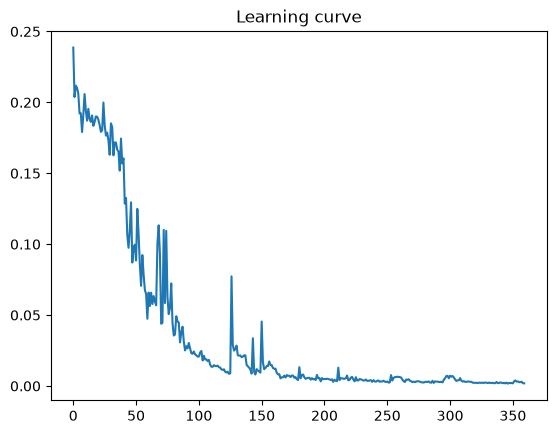

In [69]:
tss_2int = tss[[0, -1]]    # shortest + longest interval only (800, 1550 ms)
amps_2int = amps[[0, -1]]

input_train_2int, output_train_2int, mask_train_2int, ct_train_2int, ct2_train_2int = fs.create_inp_out2(
    trials_train, Nt, tss_2int, amps_2int, R_on, SR_on, perc=0.1)

hidden_size_gener = hidden_size_lr
wi_init_g, wo_init_g, m_init_g, n_init_g = structured_low_rank_init(hidden_size_gener)

net_low_rank_gener = md.OptimizedLowRankRNN(
    input_size, hidden_size_gener, output_size, std_noise_rec, alpha,
    rank=rank, train_wi=True, train_wo=True, train_h0=True,
    wi_init=wi_init_g, wo_init=wo_init_g, m_init=m_init_g, n_init=n_init_g)

loss_low_rank_gener = md.train(
    net_low_rank_gener, input_train_2int, output_train_2int, mask_train_2int,
    n_epochs=60, lr=1e-3, batch_size=batch_size, clip_gradient=1.0,
    plot_learning_curve=True, plot_gradient=False, save_loss=True)

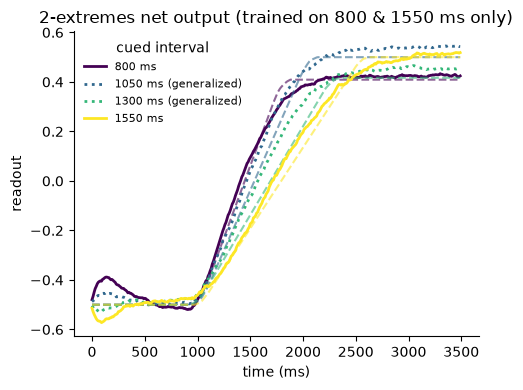

In [70]:
# Check generalization: 1050/1300 ms were never seen during training for this net
time_ms_g = np.arange(Nt) * dt
colors_g = plt.cm.viridis(np.linspace(0, 1, len(tss)))
trained_intervals = {tss_ms[0], tss_ms[-1]}

with torch.no_grad():
    out_gener = net_low_rank_gener(input_test).numpy()
target = output_test.numpy()

fig, ax = plt.subplots(figsize=(5, 4))
for i, interval in enumerate(tss_ms):
    mask = ct_test == i
    if mask.sum() == 0:
        continue
    style = '-' if interval in trained_intervals else ':'
    label = f"{interval} ms" + ('' if interval in trained_intervals else ' (generalized)')
    ax.plot(time_ms_g, out_gener[mask, :, 0].mean(0), style, color=colors_g[i], lw=2, label=label)
    ax.plot(time_ms_g, target[mask, :, 0].mean(0), '--', color=colors_g[i], alpha=0.6)
ax.set_title('2-extremes net output (trained on 800 & 1550 ms only)')
ax.set_xlabel('time (ms)')
ax.set_ylabel('readout')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(title='cued interval', frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

## 4. Train a low-rank RNN with the paper's duration-progressive curriculum

`funcs_Sphere.py`'s `gen_intervals(ts_final, N_steps, ts_min=0.4)` builds a schedule of `N_steps` stages, each
scaling all 4 target intervals by a fraction between `ts_min` and `1.0` — i.e. training starts on much shorter
(easier) versions of the task and gradually stretches to the real 800–1550 ms intervals. This schedule (and the
`prog_{i}` naming in `TrainedNets/` checkpoints) is the only curriculum mechanism actually present in the repo;
the code that ran the intermediate stages (`i=0..3`) wasn't included in the release — only the config/schedule
and the final-stage checkpoint (`prog_4`) survive. `net_low_rank_curric` below re-implements that schedule:
same architecture/init as the other two nets, but trained through all `N_steps` stages in sequence, on all 4
conditions throughout (never restricted to 2 extremes).

`USE_PRETRAINED_DURATION_CURRICULUM` toggles between running that schedule from scratch here, or loading the
paper's own checkpoint (`TrainedNets/CSG3_rank2_prog_4_rep_5_2int_gener_LRvsHR_June.pt`, `hidden_size=1500`) —
which, per the tracing above, is the actual product of this duration curriculum (its `2int_gener` name
notwithstanding).

In [71]:
USE_PRETRAINED_DURATION_CURRICULUM = False  # True: load the paper's pretrained duration-curriculum net (hidden_size=1500)

N_steps = 5
Tss_curric = fs.gen_intervals(tss_ms, N_steps, ts_min=0.4)  # shape (4, N_steps), ms, ramping 40% -> 100% of tss_ms

if USE_PRETRAINED_DURATION_CURRICULUM:
    hidden_size_curric = 1500
    net_low_rank_curric = md.OptimizedLowRankRNN(
        input_size, hidden_size_curric, output_size, std_noise_rec, alpha,
        rank=rank, train_wi=True, train_wo=True, train_h0=True)
    net_low_rank_curric.load_state_dict(torch.load(
        'TrainedNets/CSG3_rank2_prog_4_rep_5_2int_gener_LRvsHR_June.pt', map_location='cpu'))
    loss_low_rank_curric = None
    print(f'Loaded pretrained duration-curriculum RNN from TrainedNets/ (hidden_size={hidden_size_curric})')
else:
    hidden_size_curric = hidden_size_lr
    wi_init_c, wo_init_c, m_init_c, n_init_c = structured_low_rank_init(hidden_size_curric)

    net_low_rank_curric = md.OptimizedLowRankRNN(
        input_size, hidden_size_curric, output_size, std_noise_rec, alpha,
        rank=rank, train_wi=True, train_wo=True, train_h0=True,
        wi_init=wi_init_c, wo_init=wo_init_c, m_init=m_init_c, n_init=n_init_c)

    loss_low_rank_curric = []
    for stage in range(N_steps):
        tss_stage = (Tss_curric[:, stage] // dt).astype(int)
        input_train_stage, output_train_stage, mask_train_stage, _, _ = fs.create_inp_out2(
            trials_train, Nt, tss_stage, amps, R_on, SR_on, perc=0.1)
        loss_stage = md.train(
            net_low_rank_curric, input_train_stage, output_train_stage, mask_train_stage,
            n_epochs=60 // N_steps, lr=1e-3, batch_size=batch_size, clip_gradient=1.0,
            plot_learning_curve=False, plot_gradient=False, save_loss=True)
        loss_low_rank_curric.extend(loss_stage)
        print(f'stage {stage} ({Tss_curric[:, stage].astype(int)} ms): final loss={loss_stage[-1]:.4f}')

Training...
initial loss: 0.233
epoch 0:  loss=0.206  (took 1.32 s)
epoch 1:  loss=0.153  (took 1.34 s)
epoch 2:  loss=0.153  (took 1.32 s)
epoch 3:  loss=0.113  (took 1.33 s)
epoch 4:  loss=0.115  (took 1.31 s)
epoch 5:  loss=0.078  (took 1.34 s)
epoch 6:  loss=0.039  (took 1.36 s)
epoch 7:  loss=0.027  (took 1.36 s)
epoch 8:  loss=0.024  (took 1.37 s)
epoch 9:  loss=0.018  (took 1.36 s)
epoch 10:  loss=0.011  (took 1.33 s)
epoch 11:  loss=0.008  (took 1.40 s)
stage 0 ([320 420 520 620] ms): final loss=0.0079
Training...
initial loss: 0.009
epoch 0:  loss=0.272  (took 1.37 s)
epoch 1:  loss=0.204  (took 1.36 s)
epoch 2:  loss=0.096  (took 1.34 s)
epoch 3:  loss=0.019  (took 1.40 s)
epoch 4:  loss=0.015  (took 1.40 s)
epoch 5:  loss=0.030  (took 1.36 s)
epoch 6:  loss=0.018  (took 1.34 s)
epoch 7:  loss=0.015  (took 1.38 s)
epoch 8:  loss=0.008  (took 1.34 s)
epoch 9:  loss=0.005  (took 1.39 s)
epoch 10:  loss=0.004  (took 1.38 s)
epoch 11:  loss=0.003  (took 1.35 s)
stage 1 ([440 577 

## 5. Train a full-rank (unconstrained) RNN

`FullRankRNN` has an unconstrained `hidden_size x hidden_size` recurrent weight matrix. We use a smaller
`hidden_size` than the low-rank network (full-rank forward/backward passes cost `O(hidden_size^2)` per
step instead of `O(hidden_size * rank)`) and a lower learning rate, matching the relative settings used in
`Fig1_CSG.py`.

Training...
initial loss: 0.241
epoch 0:  loss=0.573  (took 2.70 s)
epoch 1:  loss=0.172  (took 2.55 s)
epoch 2:  loss=0.147  (took 2.58 s)
epoch 3:  loss=0.097  (took 2.65 s)
epoch 4:  loss=0.078  (took 2.54 s)
epoch 5:  loss=0.090  (took 2.59 s)
epoch 6:  loss=0.058  (took 2.95 s)
epoch 7:  loss=0.048  (took 2.58 s)
epoch 8:  loss=0.050  (took 2.81 s)
epoch 9:  loss=0.029  (took 2.87 s)
epoch 10:  loss=0.033  (took 2.80 s)
epoch 11:  loss=0.026  (took 2.76 s)
epoch 12:  loss=0.023  (took 2.74 s)
epoch 13:  loss=0.023  (took 2.84 s)
epoch 14:  loss=0.021  (took 3.53 s)
epoch 15:  loss=0.019  (took 2.69 s)
epoch 16:  loss=0.016  (took 2.60 s)
epoch 17:  loss=0.018  (took 2.54 s)
epoch 18:  loss=0.017  (took 2.54 s)
epoch 19:  loss=0.014  (took 2.53 s)
epoch 20:  loss=0.014  (took 2.49 s)
epoch 21:  loss=0.014  (took 2.47 s)
epoch 22:  loss=0.013  (took 2.69 s)
epoch 23:  loss=0.013  (took 2.50 s)
epoch 24:  loss=0.013  (took 2.50 s)
epoch 25:  loss=0.010  (took 2.62 s)
epoch 26:  loss=

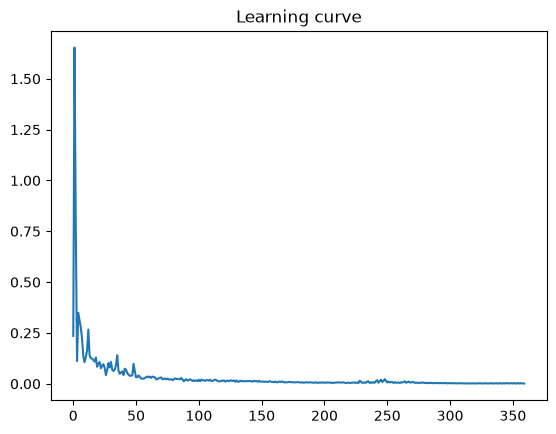

In [72]:
hidden_size_fr = 1500

net_full_rank = md.FullRankRNN(
    input_size, hidden_size_fr, output_size, 0.1 * std_noise_rec, alpha,
    train_wi=True, train_wo=True, train_h0=True)

loss_full_rank = md.train(
    net_full_rank, input_train, output_train, mask_train,
    n_epochs=60, lr=1e-4, batch_size=batch_size, clip_gradient=1.0,
    plot_learning_curve=True, plot_gradient=False, save_loss=True)

## 6. Compare learning curves

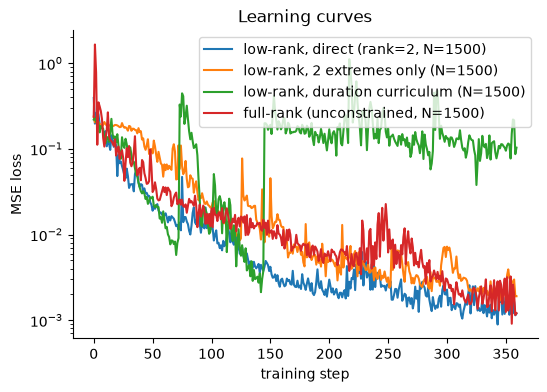

In [73]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(loss_low_rank, label=f"low-rank, direct (rank={rank}, N={hidden_size_lr})")
if loss_low_rank_gener is not None:
    ax.plot(loss_low_rank_gener, label=f"low-rank, 2 extremes only (N={hidden_size_gener})")
if loss_low_rank_curric is not None:
    ax.plot(loss_low_rank_curric, label=f"low-rank, duration curriculum (N={hidden_size_curric})")
else:
    ax.text(0.02, 0.75, 'duration-curriculum RNN: pretrained (no training curve)',
            transform=ax.transAxes, va='top', fontsize=9, color='gray')
ax.plot(loss_full_rank, label=f"full-rank (unconstrained, N={hidden_size_fr})")
ax.set_yscale('log')
ax.set_xlabel('training step')
ax.set_ylabel('MSE loss')
ax.set_title('Learning curves')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()
plt.show()

## 7. Evaluate on held-out trials

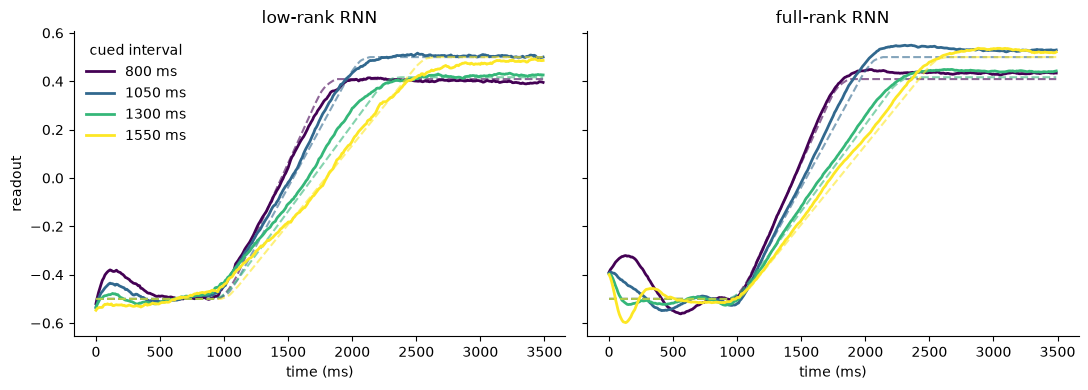

In [74]:
time_ms = np.arange(Nt) * dt
colors = plt.cm.viridis(np.linspace(0, 1, len(tss)))

with torch.no_grad():
    out_lr = net_low_rank(input_test).numpy()
    out_fr = net_full_rank(input_test).numpy()
target = output_test.numpy()

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, out, title in zip(axes, [out_lr, out_fr], ['low-rank RNN', 'full-rank RNN']):
    for i, interval in enumerate(tss_ms):
        mask = ct_test == i
        if mask.sum() == 0:
            continue
        ax.plot(time_ms, out[mask, :, 0].mean(0), color=colors[i], lw=2,
                label=f"{interval} ms")
        ax.plot(time_ms, target[mask, :, 0].mean(0), '--', color=colors[i], alpha=0.6)
    ax.set_title(title)
    ax.set_xlabel('time (ms)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
axes[0].set_ylabel('readout')
axes[0].legend(title='cued interval', frameon=False)
plt.tight_layout()
plt.show()

Solid lines are network output (averaged over held-out trials with the same cued interval), dashed lines are the
target ramps. With only 60 epochs on small networks the fit will be rough — increase `hidden_size`/`n_epochs`, or
start from the paper's structured initialization (see `give_vectors()` in `Fig1_CSG.py`), for closer-to-paper
results.

## 8. Latent-space phase portrait: direct vs. 2-extremes vs. duration-curriculum manifold

Same analysis as before (`fs.get_field`/`fs.get_manifold`, projecting the recurrent drive onto the connectivity
vectors `m1`, `m2`), computed for all three networks side by side: `net_low_rank` (direct, all 4 conditions),
`net_low_rank_gener` (2 extreme conditions only), and `net_low_rank_curric` (duration-progressive curriculum,
all 4 conditions). All three share the same `hidden_size`/`rank`/structured init, so any difference in the
resulting manifold is attributable to the training procedure, not network capacity. This reproduces the
analysis behind `Figures/Fig4_CDE/fig_06.png` in the paper.

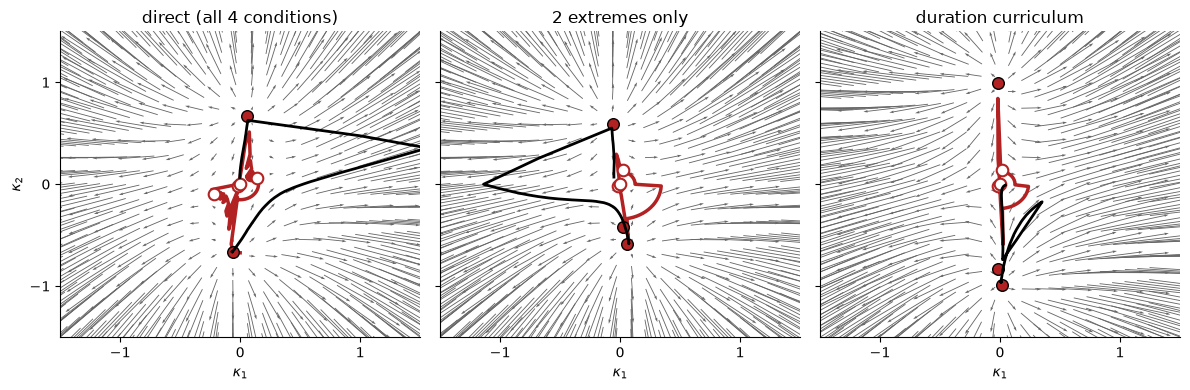

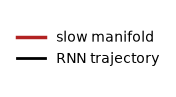

In [75]:
# --- vector field + slow manifold in (kappa1, kappa2) space, for the shortest-interval condition ---
def phase_portrait_data(net, hidden_size, Amp, k1s, k2s, thetas):
    # Computes a 2D vector field over a grid of latent coordinates (κ1, κ2)
    G0, G1, Q, m1, m2, I_pre, J_pre = fs.get_field(net, k1s, k2s, Amp, rank=rank, hidden_size=hidden_size)
    # Uses that field to find fixed points and trace out the attracting manifold
    Qs, Rth, trajs1, trajs2, st_fp, u_fp = fs.get_manifold(thetas, Q, G0, G1, k1s, k2s, m1, m2, Amp, I_pre, J_pre)
    st_fp = np.array(st_fp)
    u_fp = np.array(u_fp)

    # Actual recurrent trajectory for this condition, projected onto (kappa1, kappa2)
    input_cond, _, _, _, _ = fs.create_inp_out2(20, Nt, tss, amps, R_on, SR_on=1, just=0, perc=0.)
    with torch.no_grad():
        _, traj = net(input_cond, return_dynamics=True)
    traj = traj.numpy().mean(0)
    k1_traj = (traj @ m1) / (hidden_size * np.mean(m1 ** 2))
    k2_traj = (traj @ m2) / (hidden_size * np.mean(m2 ** 2))
    return G0, G1, Rth, st_fp, u_fp, k1_traj, k2_traj

k1s = np.linspace(-2, 2, 100)
k2s = np.linspace(-2, 2, 100)
thetas = np.linspace(-np.pi, np.pi, 150)
Amp = amps[0]

portrait_direct = phase_portrait_data(net_low_rank, hidden_size_lr, Amp, k1s, k2s, thetas)
portrait_gener = phase_portrait_data(net_low_rank_gener, hidden_size_gener, Amp, k1s, k2s, thetas)
portrait_curric = phase_portrait_data(net_low_rank_curric, hidden_size_curric, Amp, k1s, k2s, thetas)

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)
inT = 4
portraits = [portrait_direct, portrait_gener, portrait_curric]
titles = ['direct (all 4 conditions)', '2 extremes only', 'duration curriculum']
for ax, (G0, G1, Rth, st_fp, u_fp, k1_traj, k2_traj), title in zip(axes, portraits, titles):
    # Plot the vector field in (kappa1, kappa2) space
    ax.quiver(k1s[::inT], k2s[::inT], -G1[::inT, ::inT], -G0[::inT, ::inT],
              color=0.4 * np.ones(3), units='width', pivot='mid', scale=4)
    # Plot the slow manifold as a curve in (kappa1, kappa2) space
    ax.plot(Rth * np.sin(thetas), Rth * np.cos(thetas), color='firebrick', lw=2.5, label='slow manifold')
    # Plot the RNN trajectory on top of the vector field and slow manifold
    ax.plot(k2_traj, k1_traj, color='k', lw=2, zorder=5, label='RNN trajectory')
    # Plot stable and unstable fixed points, if any
    if len(st_fp):
        ax.scatter(st_fp[:, 0], st_fp[:, 1], color='firebrick', edgecolor='k', lw=1, s=70, zorder=4)
    if len(u_fp):
        ax.scatter(u_fp[:, 0], u_fp[:, 1], color='w', edgecolor='firebrick', lw=1.5, s=70, zorder=4)
    # Plot the trivial fixed point at the origin (0, 0)
    ax.scatter(0, 0, color='w', edgecolor='firebrick', lw=1.5, s=70, zorder=4)

    ax.set_xlabel(r'$\kappa_1$')
    ax.set_xlim([-1.5, 1.5])
    ax.set_ylim([-1.5, 1.5])
    ax.set_xticks([-1, 0, 1])
    ax.set_yticks([-1, 0, 1])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_title(title)
axes[0].set_ylabel(r'$\kappa_2$')
plt.tight_layout()
plt.show()

# Legend as its own small figure
legend_fig = plt.figure(figsize=(2, 1))
handles, labels = axes[0].get_legend_handles_labels()
legend_fig.legend(handles, labels, frameon=False, loc='center')
plt.axis('off')
plt.show()